In [2]:
from google.colab import files

uploaded = files.upload()


Saving greengrid_weather_solar.csv to greengrid_weather_solar (1).csv


In [3]:
import pandas as pd

df = pd.read_csv("greengrid_weather_solar.csv")

df.head()

,date,hour,temperature_c,cloud_cover_pct,uv_index,wind_speed_kmh,humidity_pct,solar_irradiance_wm2,panel_output_kwh,grid_export_kwh
0,2025-01-01,0,18.5,35.2,0.0,10.9,50.3,0.0,0.0,0.0
1,2025-01-01,1,18.5,20.4,0.0,13.3,50.9,0.0,0.0,0.0
2,2025-01-01,2,18.5,24.7,0.0,14.0,57.8,0.0,0.0,0.0
3,2025-01-01,3,18.5,29.8,0.0,9.7,58.5,0.0,0.0,0.0
4,2025-01-01,4,18.5,52.7,0.0,7.6,48.0,0.0,0.0,0.0


In [4]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset information:")
df.info()

Shape: (2160, 10)

Missing values:
date                    0
hour                    0
temperature_c           0
cloud_cover_pct         0
uv_index                0
wind_speed_kmh          0
humidity_pct            0
solar_irradiance_wm2    0
panel_output_kwh        0
grid_export_kwh         0
dtype: int64

Duplicate rows: 0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  2160 non-null   object 
 1   hour                  2160 non-null   int64  
 2   temperature_c         2160 non-null   float64
 3   cloud_cover_pct       2160 non-null   float64
 4   uv_index              2160 non-null   float64
 5   wind_speed_kmh        2160 non-null   float64
 6   humidity_pct          2160 non-null   float64
 7   solar_irradiance_wm2  2160 non-null   float64
 8   panel_output_kwh      2160 no

In [5]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date                    datetime64[ns]
hour                             int64
temperature_c                  float64
cloud_cover_pct                float64
uv_index                       float64
wind_speed_kmh                 float64
humidity_pct                   float64
solar_irradiance_wm2           float64
panel_output_kwh               float64
grid_export_kwh                float64
dtype: object


In [6]:
df.describe()

,date,hour,temperature_c,cloud_cover_pct,uv_index,wind_speed_kmh,humidity_pct,solar_irradiance_wm2,panel_output_kwh,grid_export_kwh
count,2160,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000
mean,2025-02-14 12:00:00,11.500000,26.616759,26.416806,2.020755,11.932130,55.595880,222.539444,0.391776,0.138615
min,2025-01-01 00:00:00,0.000000,16.100000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000
25%,2025-01-23 00:00:00,5.750000,23.000000,12.475000,0.000000,8.500000,45.800000,0.000000,0.000000,0.000000
50%,2025-02-14 12:00:00,11.500000,26.550000,25.450000,0.000000,12.000000,55.300000,0.000000,0.000000,0.000000
75%,2025-03-09 00:00:00,17.250000,30.200000,39.400000,4.182500,15.400000,65.300000,450.000000,0.801500,0.047250
max,2025-03-31 00:00:00,23.000000,37.400000,89.200000,8.000000,29.700000,90.000000,900.000000,1.613000,1.547000
std,NaN,6.923789,4.692954,18.028678,2.531821,5.020871,13.993786,280.313588,0.492686,0.294737


In [7]:
features = [
    "hour",
    "temperature_c",
    "cloud_cover_pct",
    "uv_index",
    "wind_speed_kmh",
    "humidity_pct",
    "solar_irradiance_wm2"
]

X = df[features]
y = df["panel_output_kwh"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (2160, 7)
Target shape: (2160,)


In [8]:
# Split data chronologically
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1728, 7)
Testing data: (432, 7)


In [9]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Create the baseline model
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print("Baseline MAE:", mae)

Baseline MAE: 0.004284722222222222


In [10]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0.000,0.000
1,0.000,0.000
2,0.000,0.000
3,0.000,0.000
4,0.000,0.000
5,0.000,0.000
6,0.000,0.000
7,0.406,0.408
8,0.625,0.627
9,0.754,0.755


In [11]:
print("GREEN GRID ENERGY - BASELINE RESULTS")
print("------------------------------------")
print("Dataset rows:", len(df))
print("Dataset columns:", len(df.columns))
print("Number of features:", X.shape[1])
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Baseline Model: Decision Tree Regressor")
print("Baseline MAE:", round(mae, 4), "kWh")

GREEN GRID ENERGY - BASELINE RESULTS
------------------------------------
Dataset rows: 2160
Dataset columns: 10
Number of features: 7
Training samples: 1728
Testing samples: 432
Baseline Model: Decision Tree Regressor
Baseline MAE: 0.0043 kWh


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Train the core model
core_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

core_model.fit(X_train, y_train)

# Make predictions
y_pred_core = core_model.predict(X_test)

# Calculate evaluation metrics
mae_core = mean_absolute_error(y_test, y_pred_core)
rmse_core = np.sqrt(mean_squared_error(y_test, y_pred_core))

print("GREEN GRID ENERGY - CORE MODEL RESULTS")
print("--------------------------------------")
print("Model: Random Forest Regressor")
print("MAE:", round(mae_core, 4), "kWh")
print("RMSE:", round(rmse_core, 4), "kWh")

GREEN GRID ENERGY - CORE MODEL RESULTS
--------------------------------------
Model: Random Forest Regressor
MAE: 0.0041 kWh
RMSE: 0.0078 kWh


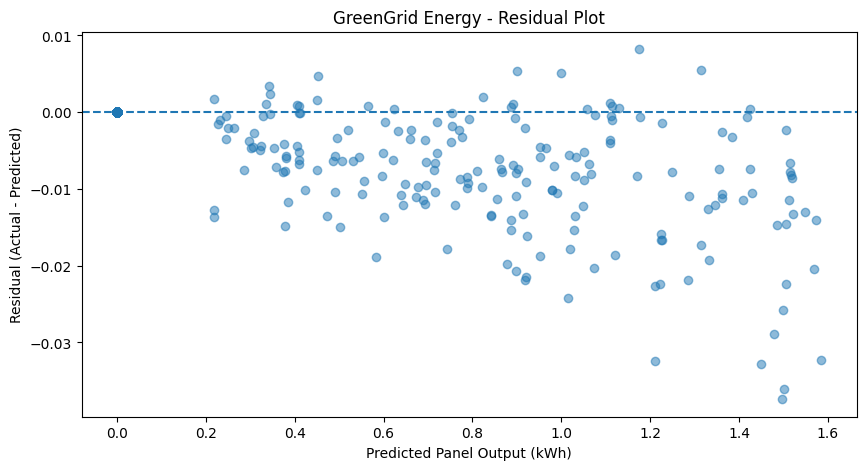

In [15]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_test - y_pred_core

# Create residual chart
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_core, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Panel Output (kWh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("GreenGrid Energy - Residual Plot")
plt.show()

In [16]:
import joblib

# Save the trained core model
joblib.dump(core_model, "greengrid_core_model.pkl")

print("Model saved successfully as greengrid_core_model.pkl")

Model saved successfully as greengrid_core_model.pkl


In [17]:
from google.colab import files

files.download("greengrid_core_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

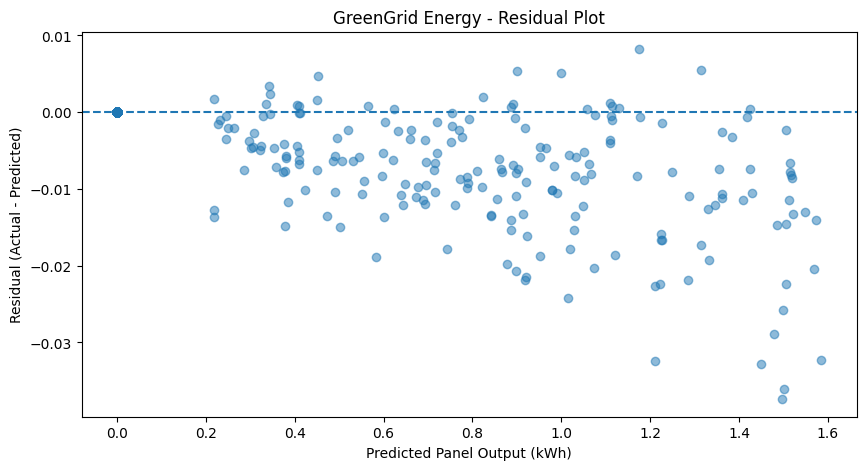

Residual chart saved successfully.


In [18]:
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_core, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Panel Output (kWh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("GreenGrid Energy - Residual Plot")

plt.savefig("greengrid_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

print("Residual chart saved successfully.")

In [19]:
from google.colab import files
files.download("greengrid_residual_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>